# Верифицируем результаты A/B-тест

Для этого:
1) Применим бутстреп для формирования выборки и расчета p_value
2) Проанализируем мощность теста и оценим его достаточность
3) Проведем A/A-тест (на контрольной группе)

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv('clean_data_part_1.csv')
df.drop('Unnamed: 0', axis=1, inplace=True)
df.head(3)

,user_id,timestamp,group,landing_page,converted
0,922696,2025-01-02 13:42:05.378582,treatment,new_page,0
1,781507,2025-01-02 13:42:15.234051,control,old_page,0
2,737319,2025-01-02 13:42:21.786186,control,old_page,0


## 1. Бутстреп

**Продублируем основные статистические значения из прошлого файла**

In [13]:
df_control = df[df['group'] == 'control']

all_control_amount = len(df_control)
converted_in_control = df_control['converted'].sum()

CR_control = converted_in_control/all_control_amount

print(f'Цифры в control: {converted_in_control} --- {all_control_amount} ---- {np.round(CR_control, 2)*100}%')
print(CR_control)

Цифры в control: 17309 --- 143818 ---- 12.0%
0.12035350234323937


In [14]:
df_treatment = df[df['group'] == 'treatment']

all_treatment_amount = len(df_treatment)
converted_in_treatment = df_treatment['converted'].sum()

CR_treatment = converted_in_treatment/all_treatment_amount

print(f'Цифры в treatment: {converted_in_treatment} --- {all_treatment_amount} ---- {np.round(CR_treatment, 2)*100}%')
print(CR_treatment)

Цифры в treatment: 17081 --- 143888 ---- 12.0%
0.11871038585566551


In [15]:
print('Абсолютная разница: ', CR_treatment - CR_control)

print(f'Процентная разница: {((CR_control/CR_treatment) - 1) * 100}%')

Абсолютная разница:  -0.0016431164875738563
Процентная разница: 1.3841387808912087%


**Построение эксперимента**

- В качестве размера выборки, для которой будем расчитывать значения, возьмем: 10.000, как типовое (можно взять и больше, тогда будет больше итераций в цикле, но 10k считается достаточным); (во время экспериментов команда проверила несколько значений - 5k, 10k, 50k, 150k)
- Что зафиксировать изменения на каждом из этапов "случайности" явно пропишем seed().

Для выбора элемента из датасета используем метод: https://www.geeksforgeeks.org/python/numpy-random-choice-in-python/

- Для оценки резульатов теста будем смотреть на доверительный интервал 95%, используем метод np.percentile: https://www.geeksforgeeks.org/python/numpy-percentile-in-python/
- Про оценку доверительного интервала и примеры кода: https://habr.com/ru/companies/X5Tech/articles/679842/

Также будем выводить p-value - для этого, полученные значения сначала сделаем смещение массива, так чтобы его середина (4999 элемент) был в условном нуле

In [24]:
np.random.seed(42)
number_of_iterations = 10000

bootstrap_storage = list()

for iter_element in range(number_of_iterations):
    choise_control = np.random.choice(df_control['converted'].values, size = all_control_amount, replace = True)
    choise_treatment = np.random.choice(df_treatment['converted'].values, size = all_treatment_amount, replace = True)
    
    bootstrap_storage.append(choise_control.mean() - choise_treatment.mean())


bootstrap_storage = np.array(bootstrap_storage)

q_low = np.percentile(bootstrap_storage, 2.5)
q_high = np.percentile(bootstrap_storage, 97.5)

center_of_bootstrap = bootstrap_storage - bootstrap_storage.mean()
boot_p_value = np.mean(np.abs(center_of_bootstrap) >= np.abs(CR_control - CR_treatment))

print(f'95% ДИ: {q_low} --- {q_high} --- {q_high - q_low}')
print(f'Бутстреп p-value: {boot_p_value}')

95% ДИ: -0.0007832915685392746 --- 0.00406199634101852 --- 0.004845287909557795
Бутстреп p-value: 0.1826


Построим визуализацию, для демонстрации теста на доверительном интервале.

Также добавим на график - нормальное распределение.

In [28]:
from scipy.stats import norm

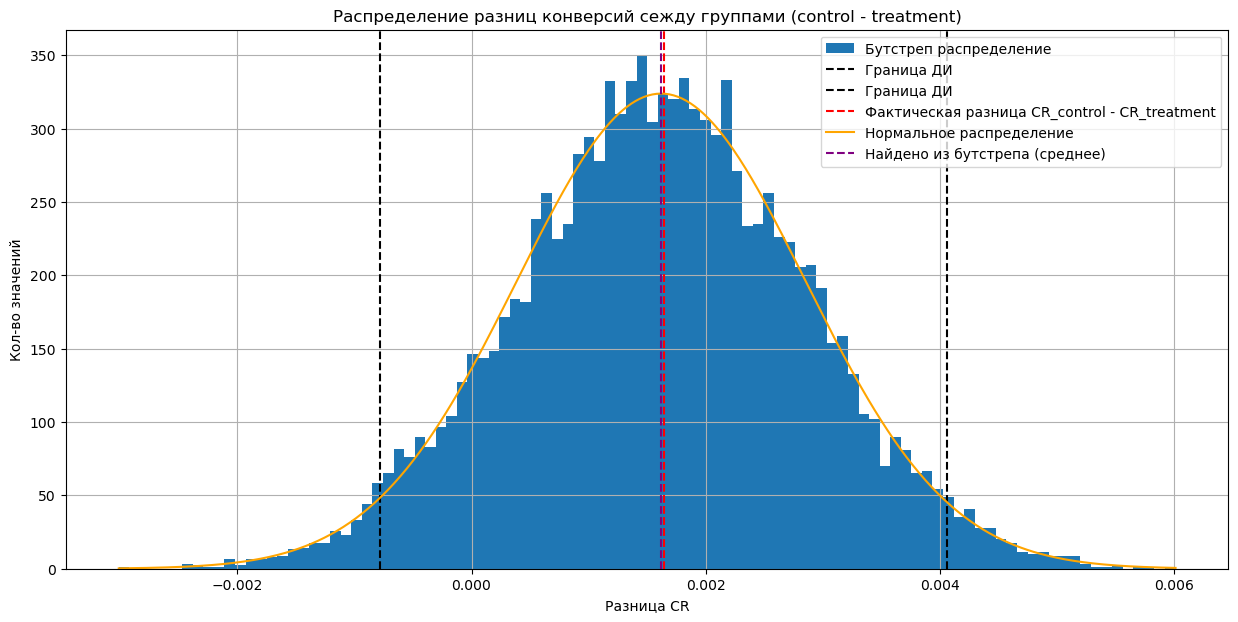

In [34]:
fig, ax = plt.subplots(figsize=(15, 7))

ax.hist(
    bootstrap_storage,
    density = True,
    bins = 100,
    label = 'Бутстреп распределение'
)


ax.axvline(
    q_low,
    color = 'black',
    linestyle = '--',
    label = 'Граница ДИ'
)
ax.axvline(
    q_high,
    color = 'black',
    linestyle = '--',
    label = 'Граница ДИ'
)


global_diff = CR_control - CR_treatment
ax.axvline(
    global_diff,
    color = 'red',
    linestyle = '--',
    label = 'Фактическая разница CR_control - CR_treatment'
)


mat_oz = bootstrap_storage.mean()
sigma_oz = bootstrap_storage.std()
data_line = np.linspace(bootstrap_storage.min(), bootstrap_storage.max(), 500)
ax.plot(data_line, norm.pdf(data_line, mat_oz, sigma_oz), color = 'orange', label = 'Нормальное распределение')


ax.axvline(
    mat_oz,
    color = 'purple',
    linestyle = '--',
    label = 'Найдено из бутстрепа (среднее)'
)


ax.set_title('Распределение разниц конверсий сежду группами (control - treatment)')
ax.set_xlabel('Разница CR')
ax.set_ylabel('Кол-во значений')
ax.legend()

plt.grid()
plt.show()

**Вывод:**
- Доверительный интервал содержит 0, следовательно H_0 может быть правдоподобным исходом;
- p-value < 0.05, следовательно сохраняем H_O

Бутстреп подтверждает результаты прошлых тестов, что статичтически значимых изменений между двумя версиями лендингов нет.

## Найдем мощность теста

Используем метод NormalIndPower().power(): https://www.statsmodels.org/stable/generated/statsmodels.stats.power.NormalIndPower.html

In [35]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

In [36]:
effect = proportion_effectsize(CR_treatment, CR_control)
effect

-0.005064912414656564

In [38]:
power_of_test = NormalIndPower().power(
    alpha = 0.05,
    effect_size = effect,
    nobs1 = all_control_amount,
    ratio = all_treatment_amount / all_control_amount,
    alternative = 'two-sided'
)
power_of_test

0.27417324574368757

Также найдем минимальный эффект, который можно статистически точно отличить (c мощностью 80%).

Для этого применим MDE метод: https://www.statsmodels.org/dev/generated/statsmodels.stats.power.NormalIndPower.solve_power.html

In [40]:
max_value_to_detect = NormalIndPower().solve_power(
    alpha = 0.05,
    power = 0.8,
    nobs1 = all_control_amount,
    ratio = all_treatment_amount / all_control_amount,
    alternative = 'two-sided'
)
max_value_to_detect

0.010446309406220948

**Вывод:**

Мощность теста при найденном пороге эффекта крайне низкая - 27%. В теории, это может свидетельствовать о недостатке данных, но поскольку мы уже проанализировали датасет на данные по каждой группе, причина такой мощности теста в том, что статистическое различие между группами крайне мало, чтобы их увидеть (поэтому алгоритму может быть нужно не 140k строк, а в 4 раза больше, например).

## Проведем A/A тест для контрольной группы

Ключевая идея - синтетически поделим контрольную группу на две и проведем сравнение метрики (CR) в каждой из них. В теории, существенных различий быть не должно.

Для разбиения используем метод np.permutation (для выбора без повторений): https://www.geeksforgeeks.org/python/numpy-random-permutation-in-python/

In [41]:
from statsmodels.stats.proportion import proportions_ztest

In [45]:
np.random.seed(42)

number_of_simulations = 5000
a = 0.05

control_values = df_control['converted'].values
len_value_control = len(control_values)

control_values

array([0, 0, 0, ..., 0, 0, 0])

In [46]:
counter = 0

for iter_item in range(number_of_simulations):
    sh = np.random.permutation(control_values)

    first_group = np.random.permutation(sh[ :len_value_control // 2])
    second_group = np.random.permutation(sh[len_value_control // 2: ])

    z_test, p_value = proportions_ztest(
        [first_group.sum(), second_group.sum()],
        [len(first_group), len(second_group)],
        alternative = 'two-sided'
    )

    if p_value < a:
        counter += 1

print(f'Число ложноположительных резульатов: {counter} --- {np.round(counter / number_of_simulations, 2) * 100}% (при пороге в 5%)')


Число ложноположительных резульатов: 274 --- 5.0% (при пороге в 5%)


**Вывод:**

Тест идеально откалеброван - это точно не из-за того, что он синтетический :)